> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 11

> 10 Juli 2024
---
---

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df_titanic = sns.load_dataset('titanic')
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Isi Missing Value Jika Ada 

In [18]:
df_titanic.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [17]:
for i in ['age', 'deck', 'embark_town']:
    df_titanic[i].fillna(df_titanic[i].mode().values[0],
                             inplace = True)

Gunakan Kolom Pclass, Age, SibSp, Parch, Fare sebagai Independent Variabel

Gunakan Kolom Survived sebagai Dependent Variabel 

In [19]:
X = df_titanic[['pclass', 'age', 'sibsp', 'parch', 'fare']]
y = df_titanic.survived

Split data menjadi Train dan Test set dengan Proporsi 80 : 20 dan random state 42 

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.8,
                                                    random_state = 42)

Lakukan Klasifikasi dengan KNN 

Lakukan Scalling pada fitur 

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lakukan Klasifikasi pada Fitur yg telah di Scalling 

In [28]:
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

Lakukan Evaluasi terhadap Model tersebut

In [29]:
print("Evaluasi pada data train:")
print(classification_report(y_train, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")

print("\nEvaluasi pada data test:")
print(classification_report(y_test, y_test_pred))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")

Evaluasi pada data train:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       444
           1       0.73      0.65      0.69       268

    accuracy                           0.78       712
   macro avg       0.77      0.75      0.76       712
weighted avg       0.78      0.78      0.77       712

Accuracy: 0.7780898876404494

Evaluasi pada data test:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       105
           1       0.71      0.57      0.63        74

    accuracy                           0.73       179
   macro avg       0.72      0.70      0.71       179
weighted avg       0.72      0.73      0.72       179

Accuracy: 0.7262569832402235


Bandingkan Evaluasi antara Train dan Test

In [ ]:
print("\nTrain set evaluation with optimal K:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_optimal)}")
print(classification_report(y_train, y_train_pred_optimal))
print(confusion_matrix(y_train, y_train_pred_optimal))

print("\nTest set evaluation with optimal K:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_optimal)}")
print(classification_report(y_test, y_test_pred_optimal))
print(confusion_matrix(y_test, y_test_pred_optimal))

Lakukan Manual Tuning untuk mencari Nilai K (tetangga) Paling optimum 

In [30]:
accuracy_scores = []
k_values = range(1, 21)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_test_pred = knn.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_test_pred))

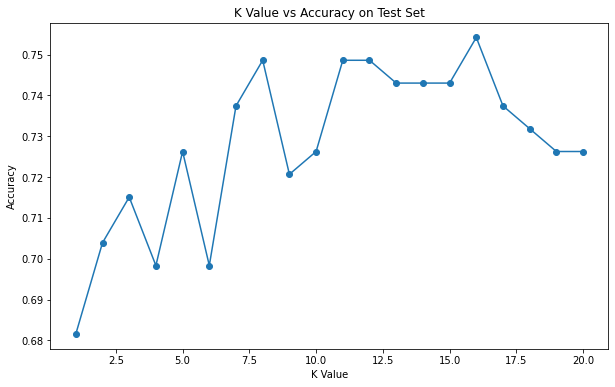

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy on Test Set')
plt.show()

In [34]:
optimal_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print(f"Optimal K: {optimal_k}")

Optimal K: 16


Lakukan Klasifikasi dan Evaluasi dengan Tetangga optimum tersebut 

In [36]:
knn_optimal = KNeighborsClassifier(n_neighbors = optimal_k)
knn_optimal.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=16)

In [37]:
y_train_pred_optimal = knn_optimal.predict(X_train_scaled)
y_test_pred_optimal = knn_optimal.predict(X_test_scaled)

In [47]:
train_accuracy = accuracy_score(y_train, y_train_pred_optimal).round(2)
print("Train set evaluation with optimal K:")
print(f"Accuracy: {train_accuracy}")
print(classification_report(y_train, y_train_pred_optimal))
print(confusion_matrix(y_train, y_train_pred_optimal))

test_accuracy = accuracy_score(y_test, y_test_pred_optimal).round(2)
print("\nTest set evaluation with optimal K:")
print(f"Accuracy: {test_accuracy}")
print(classification_report(y_test, y_test_pred_optimal))
print(confusion_matrix(y_test, y_test_pred_optimal))

Train set evaluation with optimal K:
Accuracy: 0.73
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       444
           1       0.77      0.41      0.54       268

    accuracy                           0.73       712
   macro avg       0.75      0.67      0.67       712
weighted avg       0.74      0.73      0.71       712

[[412  32]
 [158 110]]

Test set evaluation with optimal K:
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.72      0.95      0.82       105
           1       0.88      0.47      0.61        74

    accuracy                           0.75       179
   macro avg       0.80      0.71      0.72       179
weighted avg       0.78      0.75      0.73       179

[[100   5]
 [ 39  35]]


Buat Kesimpulan berdasarkan Evaluasi Model 

In [49]:
print('Kesimpulan:')
print(f'''Nilai K optimum adalah {optimal_k}
Model dengan nilai K optimum memiliki akurasi yang lebih baik pada test set dibandingkan dengan nilai K awal
dengan selisih nilai {(test_accuracy - train_accuracy).round(2)}''')

Kesimpulan:
Nilai K optimum adalah 16
Model dengan nilai K optimum memiliki akurasi yang lebih baik pada test set dibandingkan dengan nilai K awal
dengan selisih nilai 0.02
